# Tutorial 12: Analytical Orbital Maneuvers

This tutorial covers standard impulsive orbital maneuvers using analytical formulations from circular to circular/elliptical orbits.

---

## 1. Theory Prerequisite

### 1.1 Hohmann Transfer
A two-impulse maneuver that moves a spacecraft between two coplanar circular orbits of different radii using an elliptical transfer orbit.

- **Semi-major axis**: $a_{\text{trans}} = (r_1 + r_2) / 2$
- **First Burn (Perigee)**: $\Delta V_1 = | v_{\text{trans, p}} - v_{c1} |$
- **Second Burn (Apogee)**: $\Delta V_2 = | v_{c2} - v_{\text{trans, a}} |$
- **Total Delta-V**: $\Delta V_{\text{tot}} = \Delta V_1 + \Delta V_2$

### 1.2 Bi-Elliptic Transfer
A three-impulse maneuver that can be more fuel-efficient than a Hohmann transfer when the ratio of the final radius to the initial radius ($r_2 / r_1$) is greater than **15.58**.

- **Step 1**: Propel to intermediate apogee $r_b > r_2$.
- **Step 2**: Circularize/raise perigee at $r_b$ to target $r_2$.
- **Step 3**: De-circularize at $r_2$ (retrograde) from $r_b$ transfer to circular $r_2$ (Wait, standard bi-elliptic usually raises perigee or apogee. The toolkit splits it into $r_1 \rightarrow r_b \rightarrow r_2$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from opengnc.guidance.maneuvers import hohmann_transfer, bi_elliptic_transfer, plane_change

print("Imports successful.")

Imports successful.


## 2. Demonstration: Hohmann vs Bi-Elliptic

We will compare the Delta-V requirements for a Hohmann transfer and a Bi-Elliptic transfer between a low Earth orbit (LEO) and a high Earth orbit (HEO).

In [2]:
r1 = 6378.0 + 400.0  # LEO: 400 km altitude
r2 = 6378.0 + 35786.0  # GEO: 35786 km altitude
mu = 398600.4418  # Earth gravitational parameter

print(f"Initial Orbit Radius: {r1:.2f} km")
print(f"Final Orbit Radius: {r2:.2f} km")

# 1. Hohmann Transfer
dv1_h, dv2_h, t_h = hohmann_transfer(r1, r2, mu)
dv_tot_h = dv1_h + dv2_h

print("\n--- Hohmann Transfer ---")
print(f"Delta-V 1: {dv1_h:.4f} km/s")
print(f"Delta-V 2: {dv2_h:.4f} km/s")
print(f"Total Delta-V: {dv_tot_h:.4f} km/s")
print(f"Transfer Time: {t_h / 3600:.2f} hours")

# 2. Bi-Elliptic Transfer (using intermediate rb)
rb = r2 * 1.5  # Higher intermediate apogee
dv1_b, dv2_b, dv3_b, t_b = bi_elliptic_transfer(r1, r2, rb, mu)
dv_tot_b = dv1_b + dv2_b + dv3_b

print("\n--- Bi-Elliptic Transfer ---")
print(f"Intermediate Radius rb: {rb:.2f} km")
print(f"Delta-V 1: {dv1_b:.4f} km/s")
print(f"Delta-V 2: {dv2_b:.4f} km/s")
print(f"Delta-V 3: {dv3_b:.4f} km/s")
print(f"Total Delta-V: {dv_tot_b:.4f} km/s")
print(f"Transfer Time: {t_b / 3600:.2f} hours")

Initial Orbit Radius: 6778.00 km
Final Orbit Radius: 42164.00 km

--- Hohmann Transfer ---
Delta-V 1: 2.3975 km/s
Delta-V 2: 1.4565 km/s
Total Delta-V: 3.8540 km/s
Transfer Time: 5.29 hours

--- Bi-Elliptic Transfer ---
Intermediate Radius rb: 63246.00 km
Delta-V 1: 2.6382 km/s
Delta-V 2: 1.1408 km/s
Delta-V 3: 0.2935 km/s
Total Delta-V: 4.0725 km/s
Transfer Time: 25.78 hours


### 2.1 Efficiency Threshold Comparison

Bi-elliptic is better for large radius ratios ($r_2 / r_1 > 15.58$). Let's plot the total Delta-V vs Radius Ratio.

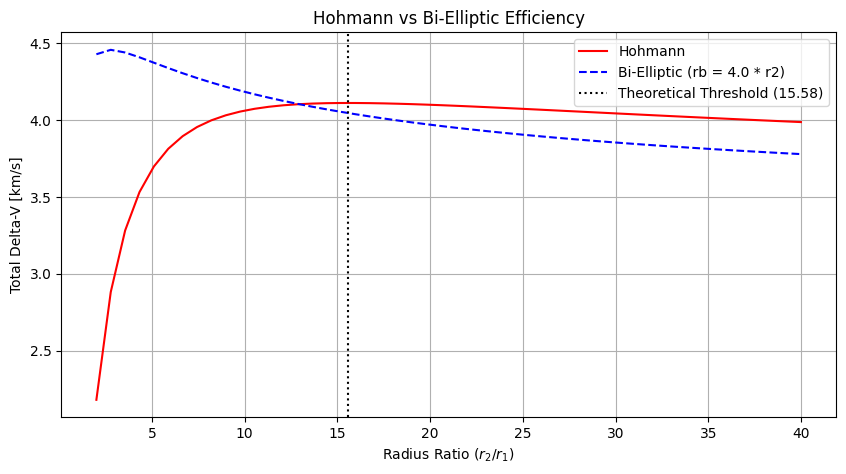

In [3]:
r_ratios = np.linspace(2, 40, 50)
dv_hohmann = []
dv_bi_elliptic = []
rb_multiplier = 4.0  # rb = r2 * rb_multiplier

for ratio in r_ratios:
    r_f = r1 * ratio
    dv1, dv2, _ = hohmann_transfer(r1, r_f, mu)
    dv_hohmann.append(dv1 + dv2)
    
    r_b = r_f * rb_multiplier
    dv1_b, dv2_b, dv3_b, _ = bi_elliptic_transfer(r1, r_f, r_b, mu)
    dv_bi_elliptic.append(dv1_b + dv2_b + dv3_b)

plt.figure(figsize=(10, 5))
plt.plot(r_ratios, dv_hohmann, 'r-', label='Hohmann')
plt.plot(r_ratios, dv_bi_elliptic, 'b--', label=f'Bi-Elliptic (rb = {rb_multiplier} * r2)')
plt.axvline(x=15.58, color='k', linestyle=':', label='Theoretical Threshold (15.58)')
plt.xlabel('Radius Ratio $(r_2 / r_1)$')
plt.ylabel('Total Delta-V [km/s]')
plt.title('Hohmann vs Bi-Elliptic Efficiency')
plt.legend()
plt.grid(True)
plt.show()

## 3. Plane Change Maneuver

Changing the inclination of an orbit requires an out-of-plane burn.

In [4]:
v_circ = np.sqrt(mu / r1)  # circular velocity at LEO
delta_i = np.radians(10.0)  # 10 degrees inclination change

dv_plane = plane_change(v_circ, delta_i)

print(f"Circular Velocity: {v_circ:.4f} km/s")
print(f"Delta-V for 10 deg Plane Change at LEO: {dv_plane:.4f} km/s")
print(f"Total Hohmann (LEO to GEO) was: {dv_tot_h:.4f} km/s")
print("Plane changes at high velocity (low altitude) are expensive!")

Circular Velocity: 7.6686 km/s
Delta-V for 10 deg Plane Change at LEO: 1.3367 km/s
Total Hohmann (LEO to GEO) was: 3.8540 km/s
Plane changes at high velocity (low altitude) are expensive!
